# Structural Breaks: Практический Pipeline

Этот ноутбук решает одну задачу: найти действительно подозрительные структурные брейки в цене, подтвержденные денежным потоком.

Логика повествования:
1. Загружаем кэшированные трейды и приводим к чистому формату.
2. Смотрим `USD volume` на полной истории и отдельно до/после cutoff-даты.
3. Применяем cutoff и формируем рабочий датасет для детектора.
4. Подбираем сглаживание цены по ликвидности, чтобы убрать шум и не потерять движение.
5. Запускаем экстрактор брейков с адаптивными порогами и `break_radius='3h'`.
6. Смотрим обзор: где брейки стоят на всей истории (цена + объем).
7. Проверяем top-5 брейков локально в окне ±12 часов, без наложений.

Итог: компактный и интерпретируемый процесс от сырых трейдов до локальной проверки брейков.

## Step 0: Environment Setup

Импортируем библиотеки и подключаем проектный код. Этот шаг делает ноутбук воспроизводимым в чистом окружении.

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "clients").exists() else cwd.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root: {REPO_ROOT}")


Repo root: /Users/anuar.aimoldin/projects/polymarket_research


In [2]:
from __future__ import annotations

import json

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

from collectors.structural_breaks import StructuralBreakConfig, StructuralBreakDetector


## Step 1: Load Cached Trades

Загружаем подготовленные трейды из кэша (`demo` pipeline). Если кэша нет, сначала запусти `/Users/anuar.aimoldin/projects/polymarket_research/examples/demo.ipynb` до шага сохранения трейдов.

На выходе ожидаем таблицу с минимумом полей:
- `timestamp_utc`
- `price`
- `size`
- `outcome` (если есть)

In [3]:
cache_dir = REPO_ROOT / "data" / "demo_cache"
trades_cache_path = cache_dir / "selected_trades.parquet"
context_cache_path = cache_dir / "selected_market_context.json"

df_trades = pd.read_parquet(trades_cache_path)
context = json.loads(context_cache_path.read_text(encoding="utf-8"))

condition_id = context.get("condition_id")
question = context.get("question")
slug = context.get("slug")

print(f"Loaded trades rows: {len(df_trades)}")
print(f"Condition id: {condition_id}")
print(f"Question: {question}")
print(f"Slug: {slug}")

df_trades.head()


Loaded trades rows: 102536
Condition id: 0xdeb615a52cd114e5aa27d8344ae506a72bea81f6ed13f5915f050b615a193c20
Question: None
Slug: None


,timestamp_utc,price,size,outcome,transaction_hash
0,2025-10-29 22:21:27+00:00,0.16,31.25000,Yes,0xd91006abd45d7cbf97eb9a102a753bc4ea2064a1edfe...
1,2025-10-29 22:21:27+00:00,0.84,31.25000,No,0xd91006abd45d7cbf97eb9a102a753bc4ea2064a1edfe...
2,2025-10-30 05:57:03+00:00,0.04,1.04165,Yes,0xe6b19028d38176d452d2644ad9b794099d24f665c90d...
3,2025-10-30 05:57:03+00:00,0.96,1.04165,No,0xe6b19028d38176d452d2644ad9b794099d24f665c90d...
4,2025-10-30 05:57:07+00:00,0.85,1.00000,No,0x8a1c9648bdc6ee6fac6c7b9ff58290b1a3ec8a29c878...


In [4]:
df_trades['size'].sum()

np.float64(106937313.61655399)

In [5]:
df_trades["size"].describe()


count    102536.000000
mean       1042.924569
std        7142.313148
min           0.010000
25%          11.960000
50%          40.000000
75%         178.580000
max      711689.270000
Name: size, dtype: float64

## Step 2: USD Volume on Full History

Первый диагностический блок: денежный поток (`usd_volume = sum(price * size)`) на полной истории.

В этой секции строим общий график `USD volume`, чтобы увидеть глобальную структуру ликвидности
и подготовить обоснование для cutoff в следующем шаге.

Full-history valid trades: 102536
Full-history range: 2025-10-29 22:21:27+00:00 .. 2026-02-19 12:26:46+00:00
Configured cutoff_date: 2026-01-15 00:00:00+00:00


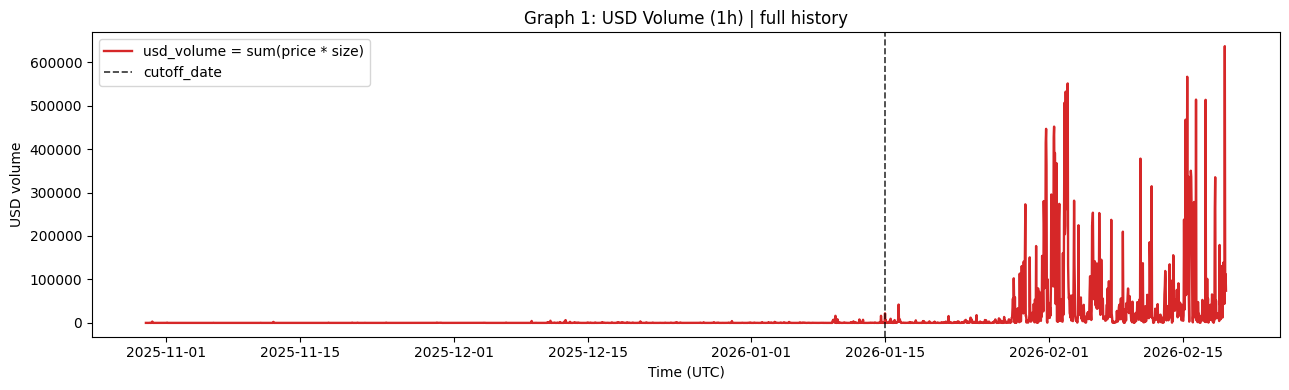

In [6]:
analysis_interval = "1h"
cutoff_date = pd.Timestamp("2026-01-15", tz="UTC")  # configurable

df_trades["timestamp_utc"] = pd.to_datetime(df_trades["timestamp_utc"], utc=True, errors="coerce")

trades_all = (
    df_trades.assign(
        price=lambda d: pd.to_numeric(d["price"], errors="coerce"),
        size=lambda d: pd.to_numeric(d["size"], errors="coerce"),
    )
    .dropna(subset=["timestamp_utc", "price", "size"])
    .sort_values("timestamp_utc")
    .reset_index(drop=True)
)

if trades_all.empty:
    raise ValueError("No valid trades after cleaning.")

trades_all["usd_notional"] = trades_all["price"] * trades_all["size"]

bucket_all = (
    trades_all.set_index("timestamp_utc")
    .resample(analysis_interval)
    .agg(
        n_trades=("price", "size"),
        volume=("size", "sum"),
        usd_volume=("usd_notional", "sum"),
    )
    .assign(
        n_trades=lambda d: d["n_trades"].fillna(0).astype(int),
        volume=lambda d: d["volume"].fillna(0.0),
        usd_volume=lambda d: d["usd_volume"].fillna(0.0),
    )
)

print(f"Full-history valid trades: {len(trades_all)}")
print(f"Full-history range: {trades_all['timestamp_utc'].min()} .. {trades_all['timestamp_utc'].max()}")
print(f"Configured cutoff_date: {cutoff_date}")

fig = plt.figure(figsize=(13, 4))
ax = fig.add_subplot(111)
ax.plot(bucket_all.index, bucket_all["usd_volume"], color="tab:red", linewidth=1.7, label="usd_volume = sum(price * size)")
ax.axvline(cutoff_date, color="black", linestyle="--", linewidth=1.2, alpha=0.8, label="cutoff_date")
ax.set_title(f"Graph 1: USD Volume ({analysis_interval}) | full history")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("USD volume")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

Далее фиксируем рабочий период через cutoff и отдельно сравниваем `USD volume` до и после cutoff.

### Как читать Graph 1

- Высокие пики `usd_volume` = интервалы с максимальным денежным потоком.
- Длинные низкие участки = зоны, где сигнал брейка потенциально менее надежен.
- Локальное сравнение до/после cutoff выполняется в следующем шаге.

## Step 3: Apply Cutoff and Compare Before/After

Применяем cutoff и формируем рабочий датасет для всех следующих шагов.

В этом шаге также строим сравнительные графики `USD volume`:
- только период до cutoff,
- только период после cutoff.

Это делает переход к post-cutoff анализу явным и визуально проверяемым.

Rows before cutoff: 102536
Rows after cutoff:  96705
Liquidity stats (post-cutoff):
- interval: 1h
- mean_usd_volume: 41709.20385362134
- median_usd_volume: 7439.75903
- mean_trades_per_interval: 113.3704572098476
- median_trades_per_interval: 55.0
- median_inter_trade_raw_sec: 0.0
- median_inter_trade_nonzero_sec: 20.0
- mean_inter_trade_sec: 31.733785572468562


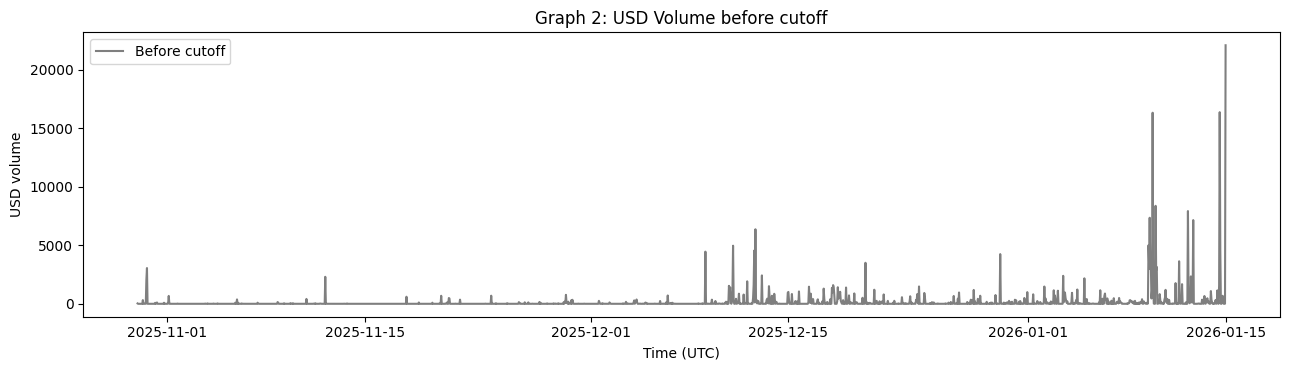

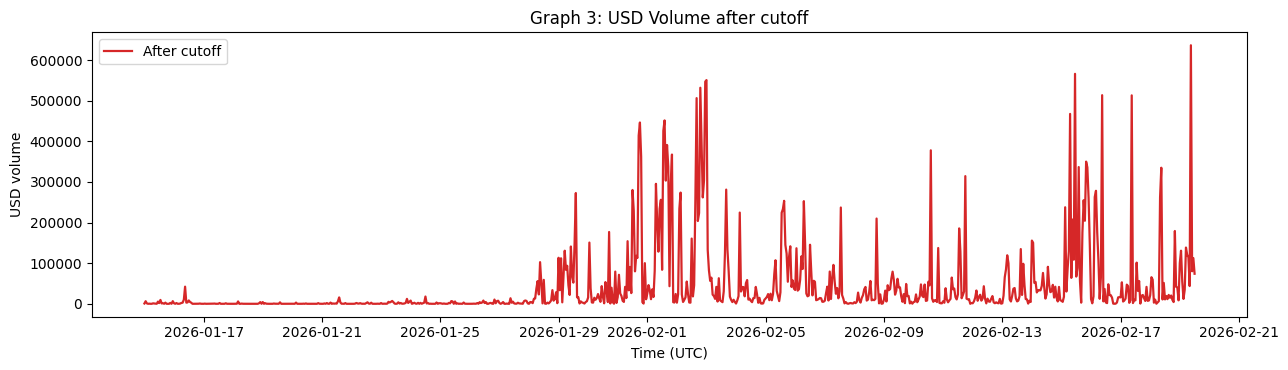

In [7]:
analysis_trades = trades_all.loc[trades_all["timestamp_utc"] >= cutoff_date].copy().reset_index(drop=True)
if analysis_trades.empty:
    raise ValueError(
        f"No trades after cutoff >= {cutoff_date}. Available range: "
        f"{trades_all['timestamp_utc'].min()} .. {trades_all['timestamp_utc'].max()}"
    )

bucket_before = bucket_all.loc[bucket_all.index < cutoff_date]
bucket_after = bucket_all.loc[bucket_all.index >= cutoff_date]

# Downstream code uses these canonical variables
trades = analysis_trades.copy()
trades["inter_trade_sec"] = trades["timestamp_utc"].diff().dt.total_seconds()
inter_trade_raw = trades["inter_trade_sec"].dropna()
inter_trade_nonzero = inter_trade_raw[inter_trade_raw > 0]

median_inter_trade_raw = float(inter_trade_raw.median()) if len(inter_trade_raw) else float("nan")
median_inter_trade_nonzero = float(inter_trade_nonzero.median()) if len(inter_trade_nonzero) else float("nan")
mean_inter_trade = float(inter_trade_raw.mean()) if len(inter_trade_raw) else float("nan")

trades["usd_notional"] = trades["price"] * trades["size"]

bucket = (
    trades.set_index("timestamp_utc")
    .resample(analysis_interval)
    .agg(
        n_trades=("price", "size"),
        volume=("size", "sum"),
        usd_volume=("usd_notional", "sum"),
        price_end=("price", "last"),
        price_avg=("price", "mean"),
    )
    .assign(
        n_trades=lambda d: d["n_trades"].fillna(0).astype(int),
        volume=lambda d: d["volume"].fillna(0.0),
        usd_volume=lambda d: d["usd_volume"].fillna(0.0),
        price_avg=lambda d: d["price_avg"].ffill().bfill(),
    )
)

liquidity_stats = {
    "interval": analysis_interval,
    "mean_usd_volume": float(bucket["usd_volume"].mean()),
    "median_usd_volume": float(bucket["usd_volume"].median()),
    "mean_trades_per_interval": float(bucket["n_trades"].mean()),
    "median_trades_per_interval": float(bucket["n_trades"].median()),
    "median_inter_trade_raw_sec": median_inter_trade_raw,
    "median_inter_trade_nonzero_sec": median_inter_trade_nonzero,
    "mean_inter_trade_sec": mean_inter_trade,
}

print(f"Rows before cutoff: {len(trades_all)}")
print(f"Rows after cutoff:  {len(analysis_trades)}")
print("Liquidity stats (post-cutoff):")
for k, v in liquidity_stats.items():
    print(f"- {k}: {v}")

fig = plt.figure(figsize=(13, 3.8))
ax = fig.add_subplot(111)
ax.plot(bucket_before.index, bucket_before["usd_volume"], color="tab:gray", linewidth=1.5, label="Before cutoff")
ax.set_title("Graph 2: USD Volume before cutoff")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("USD volume")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(13, 3.8))
ax = fig.add_subplot(111)
ax.plot(bucket_after.index, bucket_after["usd_volume"], color="tab:red", linewidth=1.6, label="After cutoff")
ax.set_title("Graph 3: USD Volume after cutoff")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("USD volume")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Step 4: Liquidity-Aware Price Smoothing (Graph 4)

Строим сглаженную цену на данных после cutoff.

Идея:
- Если ликвидность низкая, цена “рваная”, нужно более сильное сглаживание.
- Если ликвидность выше, можно сглаживать слабее, чтобы сохранить локальные движения.

Этот же smoothing используется при визуализации найденных брейков.

Chosen smoothing span: 24 intervals (6.0h)
Liquidity regime: high liquidity


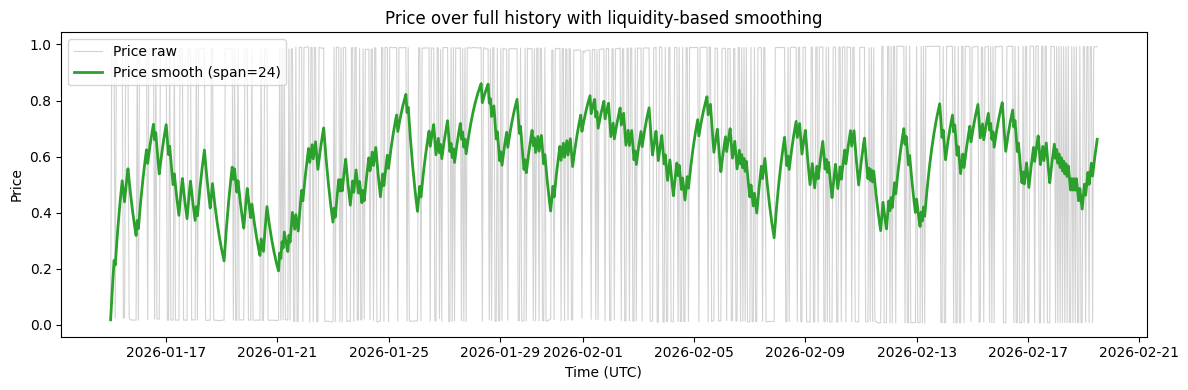

In [8]:
def choose_smoothing_span(
    *,
    median_inter_trade_nonzero_sec: float,
    median_trades_per_interval: float,
    interval_minutes: int,
) -> tuple[int, str]:
    # Чем хуже ликвидность, тем больше окно сглаживания.
    if median_inter_trade_nonzero_sec > 180 or median_trades_per_interval < 1.5:
        hours = 48
        reason = "very low liquidity"
    elif median_inter_trade_nonzero_sec > 90 or median_trades_per_interval < 3:
        hours = 24
        reason = "low liquidity"
    elif median_inter_trade_nonzero_sec > 30 or median_trades_per_interval < 8:
        hours = 12
        reason = "medium liquidity"
    else:
        hours = 6
        reason = "high liquidity"

    span_intervals = max(4, int((hours * 60) / interval_minutes))
    return span_intervals, reason

interval_minutes = 15
median_nonzero_sec = float(liquidity_stats["median_inter_trade_nonzero_sec"])
median_trades = float(liquidity_stats["median_trades_per_interval"])

smoothing_span, liquidity_label = choose_smoothing_span(
    median_inter_trade_nonzero_sec=median_nonzero_sec,
    median_trades_per_interval=median_trades,
    interval_minutes=interval_minutes,
)

bucket_price = bucket.copy()
bucket_price["price_raw"] = bucket_price["price_end"].ffill()
bucket_price["price_smooth"] = bucket_price["price_raw"].ewm(span=smoothing_span, adjust=False, min_periods=1).mean()

print(f"Chosen smoothing span: {smoothing_span} intervals ({smoothing_span * interval_minutes / 60:.1f}h)")
print(f"Liquidity regime: {liquidity_label}")

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(111)
ax.plot(bucket_price.index, bucket_price["price_raw"], color="tab:gray", linewidth=0.8, alpha=0.35, label="Price raw")
ax.plot(bucket_price.index, bucket_price["price_smooth"], color="tab:green", linewidth=2.0, label=f"Price smooth (span={smoothing_span})")
ax.set_title("Price over full history with liquidity-based smoothing")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Price")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


После выбора сглаживания переходим к детектору брейков с ограничением по числу событий (`max_breaks`).

### Интерпретация Graph 4

- График показывает тренд цены после подавления микрошума.
- Если линия все еще слишком шумная, увеличивай `smoothing_span`.
- Если линия слишком плоская и теряются события, уменьшай `smoothing_span`.

## Step 5: Run Structural Break Extractor (with non-overlap radius)

Запускаем детектор с порогами, зависящими от ликвидности.

### Как работает детектор
1. Агрегирует трейды по `analysis_interval`.
2. Для каждого интервала считает:
- сдвиг цены (`price_return_pct`),
- объем,
- baseline объема (медиана исторического окна),
- отношение к baseline (`volume_ratio`).
3. Помечает кандидата в брейк, если выполнено одно из правил:
- значимый сдвиг цены + всплеск объема,
- сильный сдвиг цены + хотя бы существенный объем.
4. Фильтрует низкообъемные сдвиги цены.
5. Применяет `break_radius='3h'`: если брейки пересекаются по радиусу, оставляет только самый сильный (`score`).
6. Применяет `max_breaks` как финальный лимит количества событий.

Результат шага:
- `candidates`: уже очищенные от пересечений по `break_radius`.
- `breaks`: итоговые события после `max_breaks`.

Детектор в этом ноутбуке работает на данных после `cutoff_date`.

In [9]:
# Адаптивная строгость порогов по ликвидности
if liquidity_label == "very low liquidity":
    price_change_pct = 3.5
    strong_price_change_pct = 7.0
    volume_surge_ratio = 2.8
    volume_substantial_ratio = 1.2
    max_breaks = 8
elif liquidity_label == "low liquidity":
    price_change_pct = 3.0
    strong_price_change_pct = 6.0
    volume_surge_ratio = 2.5
    volume_substantial_ratio = 1.1
    max_breaks = 10
elif liquidity_label == "medium liquidity":
    price_change_pct = 2.5
    strong_price_change_pct = 5.0
    volume_surge_ratio = 2.2
    volume_substantial_ratio = 1.0
    max_breaks = 12
else:
    price_change_pct = 2.0
    strong_price_change_pct = 4.0
    volume_surge_ratio = 2.0
    volume_substantial_ratio = 0.9
    max_breaks = 10

sb_config = StructuralBreakConfig(
    interval=analysis_interval,
    baseline_window=96,
    baseline_min_periods=24,
    outcome=None,
    auto_select_outcome=True,
    price_change_pct=price_change_pct,
    strong_price_change_pct=strong_price_change_pct,
    volume_surge_ratio=volume_surge_ratio,
    volume_substantial_ratio=volume_substantial_ratio,
    low_volume_ratio=0.40,
    min_break_score=None,
    max_breaks=max_breaks,
    break_radius="3h",
    min_trades_per_interval=2,
    merge_consecutive_breaks=True,
    merge_gap_intervals=2,
    max_annotations=8,
    plot_price_smoothing_span=smoothing_span,
    plot_volume_smoothing_span=max(8, smoothing_span // 2),
    plot_volume_clip_quantile=0.99,
    plot_show_raw_price=False,
)

sb_detector = StructuralBreakDetector(sb_config)
sb_result = sb_detector.detect(analysis_trades)

print("Structural-break summary:")
for k, v in sb_result.summary.items():
    print(f"- {k}: {v}")

breaks_df = sb_result.breaks.copy()
print(f"\nCandidates after break_radius (before max_breaks cap): {len(sb_result.candidates)}")
print(f"Selected breaks: {len(breaks_df)}")
display(breaks_df.head(25))


Structural-break summary:
- interval: 1h
- n_intervals: 853
- n_breaks: 10
- n_candidates_before_cap: 98
- selected_outcome: Yes
- price_change_pct: 2.0
- strong_price_change_pct: 4.0
- volume_surge_ratio: 2.0
- volume_substantial_ratio: 0.9
- low_volume_ratio: 0.4
- min_break_score: None
- max_breaks: 10
- break_radius: 3h
- score_threshold_selected: 24.53050861886959
- median_abs_return_pct: 5.882352269618707
- median_volume_ratio: 1.2592523002289426
- score_min: 2.7179814100108395
- score_q50: 9.574637254814267
- score_q75: 13.775826941591168
- score_q90: 24.08359681779049
- score_q95: 35.3209362832824
- score_q99: 77.45551041585979
- score_max: 77.68221287928466

Candidates after break_radius (before max_breaks cap): 98
Selected breaks: 10


,break_timestamp,price_end,price_return_pct,abs_price_return_pct,volume,volume_baseline,volume_ratio,n_trades,reason,score
0,2026-01-21 14:00:00+00:00,0.012,-25.000000,25.000000,2.138237e+04,219.675625,97.336111,83,volume_surge_and_price_shift,34.927446
1,2026-01-21 22:00:00+00:00,0.011,22.222222,22.222222,7.473655e+03,253.930406,29.431904,9,volume_surge_and_price_shift,24.530509
2,2026-01-23 21:00:00+00:00,0.015,50.000000,50.000000,1.056457e+05,577.506954,182.934006,79,volume_surge_and_price_shift,77.682213
3,2026-01-26 20:00:00+00:00,0.021,61.538462,61.538462,6.148654e+04,1107.965000,55.495017,52,volume_surge_and_price_shift,77.448499
4,2026-01-27 09:00:00+00:00,0.014,27.272727,27.272727,1.749552e+04,1170.801043,14.943207,39,volume_surge_and_price_shift,25.697951
5,2026-01-28 12:00:00+00:00,0.017,30.769231,30.769231,5.883842e+04,1238.666500,47.501421,51,volume_surge_and_price_shift,37.550716
6,2026-01-30 19:00:00+00:00,0.019,58.333333,58.333333,6.501909e+05,14854.450782,43.770782,96,volume_surge_and_price_shift,70.022688
7,2026-02-11 14:00:00+00:00,0.008,-33.333333,33.333333,2.011606e+06,27557.142431,72.997628,161,volume_surge_and_price_shift,44.200275
8,2026-02-14 22:00:00+00:00,0.009,28.571429,28.571429,1.311768e+06,47973.569318,27.343565,103,volume_surge_and_price_shift,31.031429
9,2026-02-15 21:00:00+00:00,0.008,33.333333,33.333333,9.650043e+05,60995.317533,15.820957,72,volume_surge_and_price_shift,31.855213


## Step 6: Overview of Detected Breaks on Full History

Перед локальной проверкой смотрим 2 общих графика с теми же брейками:
- Graph 3: цена по всей истории + отметки моментов брейка.
- Graph 4: `USD volume` по всей истории + отметки моментов брейка.
- Полупрозрачные полосы показывают `break_radius` вокруг каждого брейка.

Так проще быстро понять, где детектор сработал относительно глобального режима рынка и как работает запрет на пересечение событий.

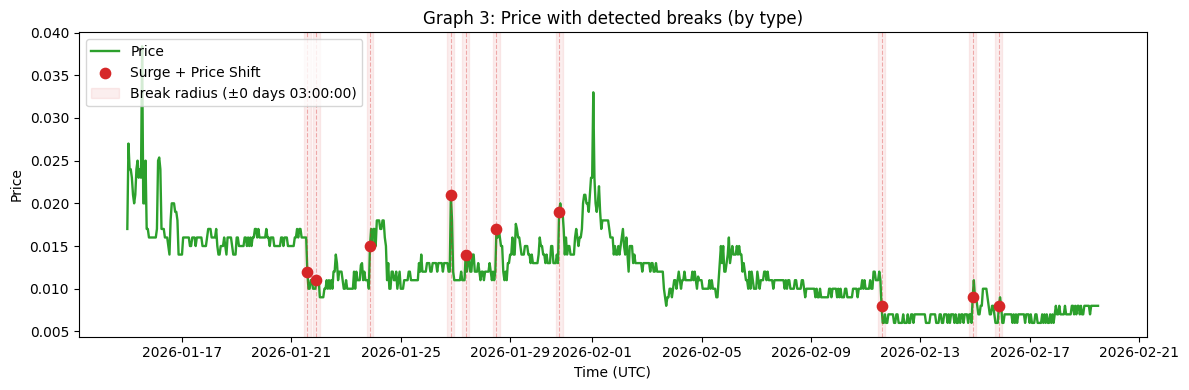

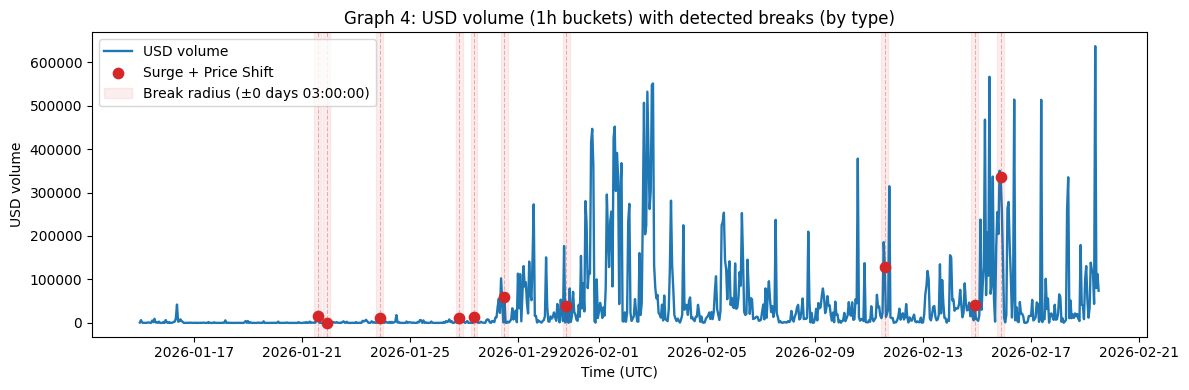

In [10]:
bars = sb_result.bars.copy()
breaks_df = sb_result.breaks.copy()

reason_colors = {
    "volume_surge_and_price_shift": "tab:red",
    "substantial_volume_and_strong_price_shift": "tab:orange",
}
reason_labels = {
    "volume_surge_and_price_shift": "Surge + Price Shift",
    "substantial_volume_and_strong_price_shift": "Substantial Vol + Strong Price Shift",
}

if breaks_df.empty:
    breaks_df_plot = pd.DataFrame(columns=["break_timestamp", "reason"])
else:
    breaks_df_plot = breaks_df.copy()
    breaks_df_plot["break_timestamp"] = pd.to_datetime(
        breaks_df_plot["break_timestamp"], utc=True, errors="coerce"
    )
    breaks_df_plot = breaks_df_plot.dropna(subset=["break_timestamp"]).sort_values("break_timestamp")

# Radius window used in detector (for visualization)
try:
    break_radius = pd.to_timedelta(getattr(sb_config, "break_radius", None))
    if pd.isna(break_radius) or break_radius <= pd.Timedelta(0):
        break_radius = None
except Exception:
    break_radius = None

# --- Graph 3: Price + typed breaks + radius bands
fig, ax = plt.subplots(figsize=(12, 4))
price_col = "price_plot" if "price_plot" in bars.columns else "price_end"
ax.plot(bars.index, bars[price_col], color="tab:green", linewidth=1.7, label="Price")

radius_label_used = False
if not breaks_df_plot.empty:
    for reason, grp in breaks_df_plot.groupby("reason", dropna=False):
        color = reason_colors.get(str(reason), "tab:purple")
        label = reason_labels.get(str(reason), str(reason))
        ts = pd.DatetimeIndex(grp["break_timestamp"])
        yb = bars[price_col].reindex(ts).ffill().bfill()
        ax.scatter(ts, yb, color=color, s=55, zorder=5, label=label)
        for t in ts:
            if break_radius is not None:
                lbl = f"Break radius (±{break_radius})" if not radius_label_used else None
                ax.axvspan(t - break_radius, t + break_radius, color=color, alpha=0.08, label=lbl)
                radius_label_used = True
            ax.axvline(t, color=color, linestyle="--", linewidth=0.8, alpha=0.35)

ax.set_title("Graph 3: Price with detected breaks (by type)")
ax.set_ylabel("Price")
ax.set_xlabel("Time (UTC)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# --- Graph 4: USD volume + typed breaks + radius bands
usd_series = (
    analysis_trades.assign(
        timestamp_utc=pd.to_datetime(analysis_trades["timestamp_utc"], utc=True, errors="coerce"),
        price=pd.to_numeric(analysis_trades["price"], errors="coerce"),
        size=pd.to_numeric(analysis_trades["size"], errors="coerce"),
    )
    .dropna(subset=["timestamp_utc", "price", "size"])
    .assign(usd_notional=lambda x: x["price"] * x["size"])
    .set_index("timestamp_utc")["usd_notional"]
    .resample(analysis_interval)
    .sum()
    .reindex(bars.index)
    .fillna(0.0)
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(usd_series.index, usd_series.values, color="tab:blue", linewidth=1.7, label="USD volume")

radius_label_used = False
if not breaks_df_plot.empty:
    for reason, grp in breaks_df_plot.groupby("reason", dropna=False):
        color = reason_colors.get(str(reason), "tab:purple")
        label = reason_labels.get(str(reason), str(reason))
        ts = pd.DatetimeIndex(grp["break_timestamp"])
        vb = usd_series.reindex(ts).ffill().bfill()
        ax.scatter(ts, vb, color=color, s=55, zorder=5, label=label)
        for t in ts:
            if break_radius is not None:
                lbl = f"Break radius (±{break_radius})" if not radius_label_used else None
                ax.axvspan(t - break_radius, t + break_radius, color=color, alpha=0.08, label=lbl)
                radius_label_used = True
            ax.axvline(t, color=color, linestyle="--", linewidth=0.8, alpha=0.35)

ax.set_title(f"Graph 4: USD volume ({analysis_interval} buckets) with detected breaks (by type)")
ax.set_ylabel("USD volume")
ax.set_xlabel("Time (UTC)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

После обзорных графиков переходим к короткому списку top-5 и локальным окнам вокруг каждого события.

## Step 7: Local Validation of Top-5 Breaks (±12h, No Overlays)

Финальная проверка делается локально по каждому брейку отдельно.

Для каждого из top-5:
- Окно `12 часов до` и `12 часов после` точки брейка.
- Отдельная фигура (без наложения разных брейков).
- Верх: цена, низ: `USD volume`.
- Вертикальная линия показывает точный момент брейка.

Зачем это нужно:
- Быстро увидеть, был ли брейк действительно “событийным”, а не артефактом порогов.

In [11]:
breaks_df = sb_result.breaks.copy()
if breaks_df.empty:
    raise ValueError("No breaks selected. Relax thresholds or increase max_breaks.")

top_n = min(5, len(breaks_df))
top_breaks = breaks_df.sort_values("score", ascending=False).head(top_n).reset_index(drop=True)

show_cols = ["break_timestamp", "reason", "score", "price_return_pct", "volume_ratio", "volume"]
show_cols = [c for c in show_cols if c in top_breaks.columns]

display(top_breaks[show_cols])


,break_timestamp,reason,score,price_return_pct,volume_ratio,volume
0,2026-01-23 21:00:00+00:00,volume_surge_and_price_shift,77.682213,50.000000,182.934006,1.056457e+05
1,2026-01-26 20:00:00+00:00,volume_surge_and_price_shift,77.448499,61.538462,55.495017,6.148654e+04
2,2026-01-30 19:00:00+00:00,volume_surge_and_price_shift,70.022688,58.333333,43.770782,6.501909e+05
3,2026-02-11 14:00:00+00:00,volume_surge_and_price_shift,44.200275,-33.333333,72.997628,2.011606e+06
4,2026-01-28 12:00:00+00:00,volume_surge_and_price_shift,37.550716,30.769231,47.501421,5.883842e+04


Ниже будет компактная таблица самых подозрительных брейков для ручной проверки.

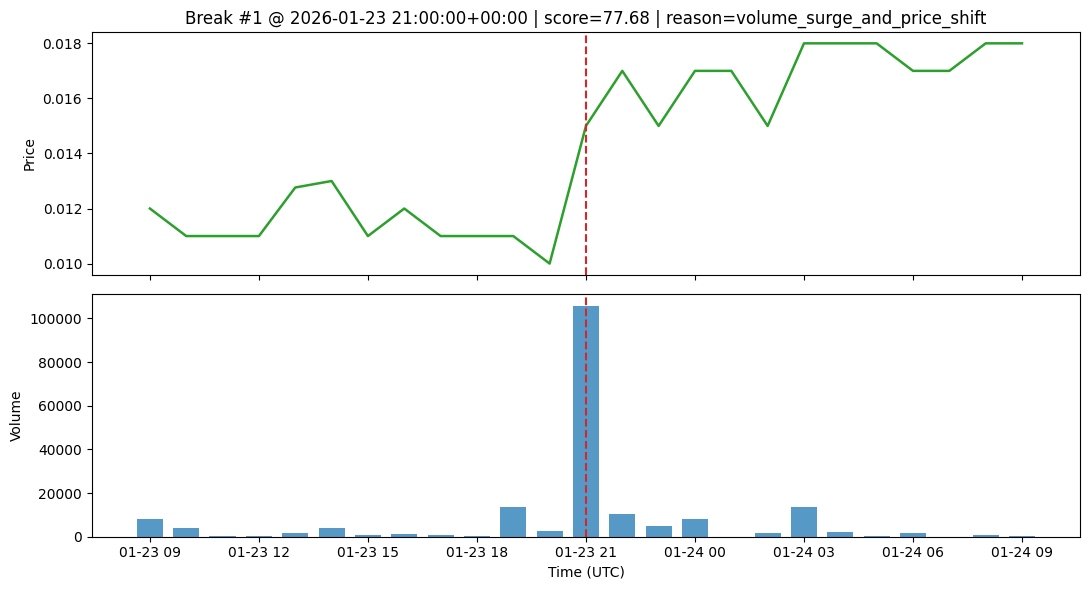

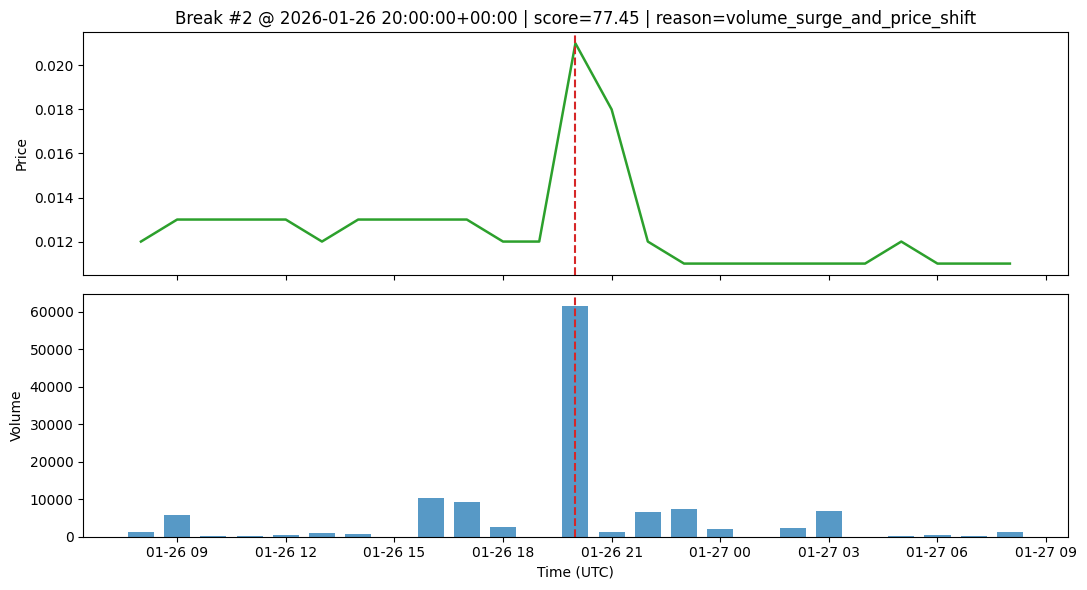

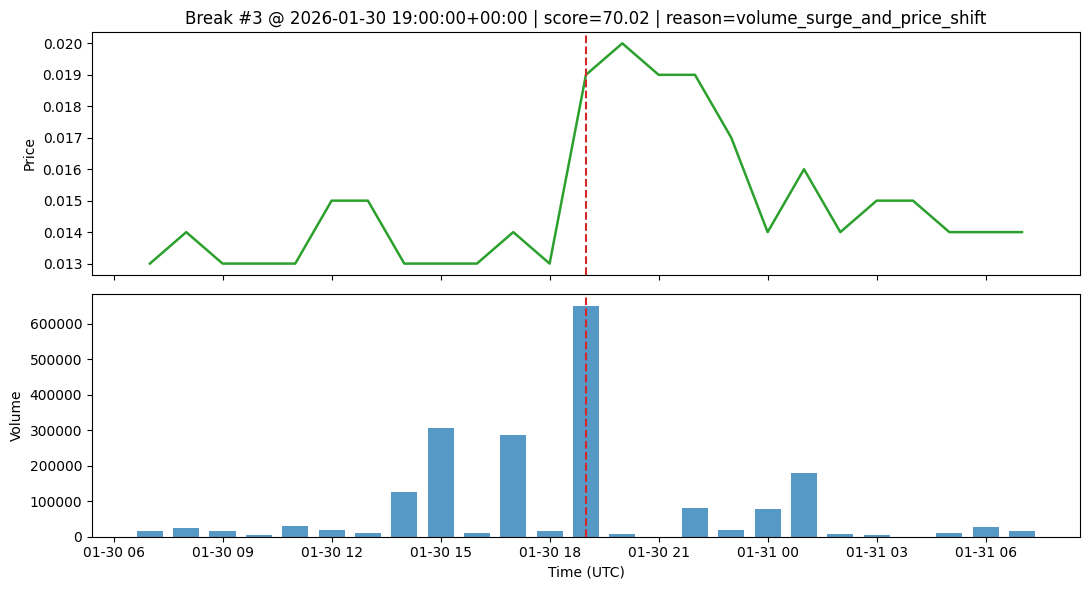

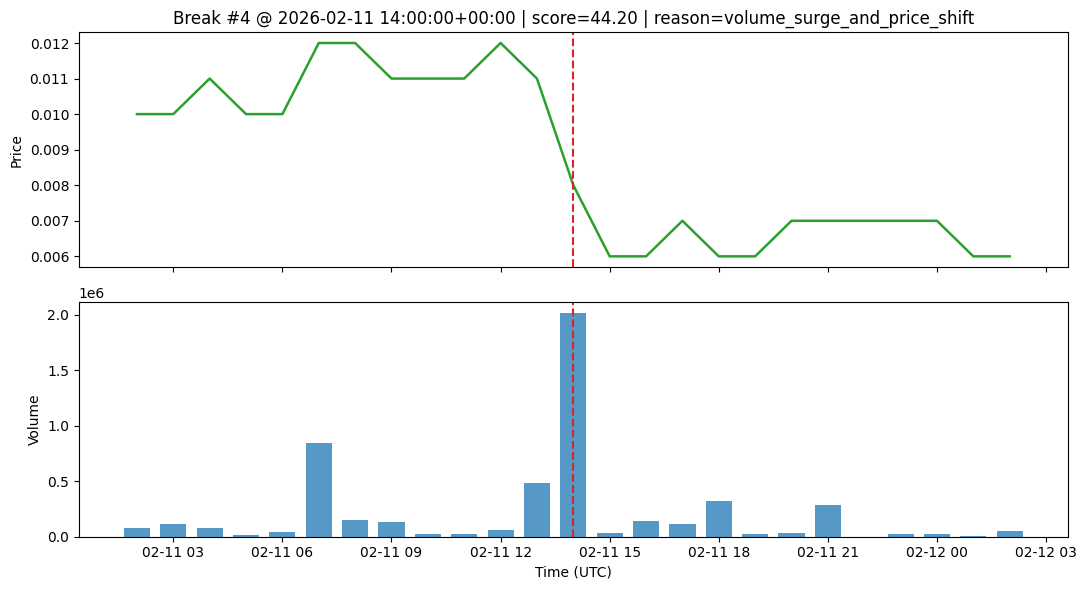

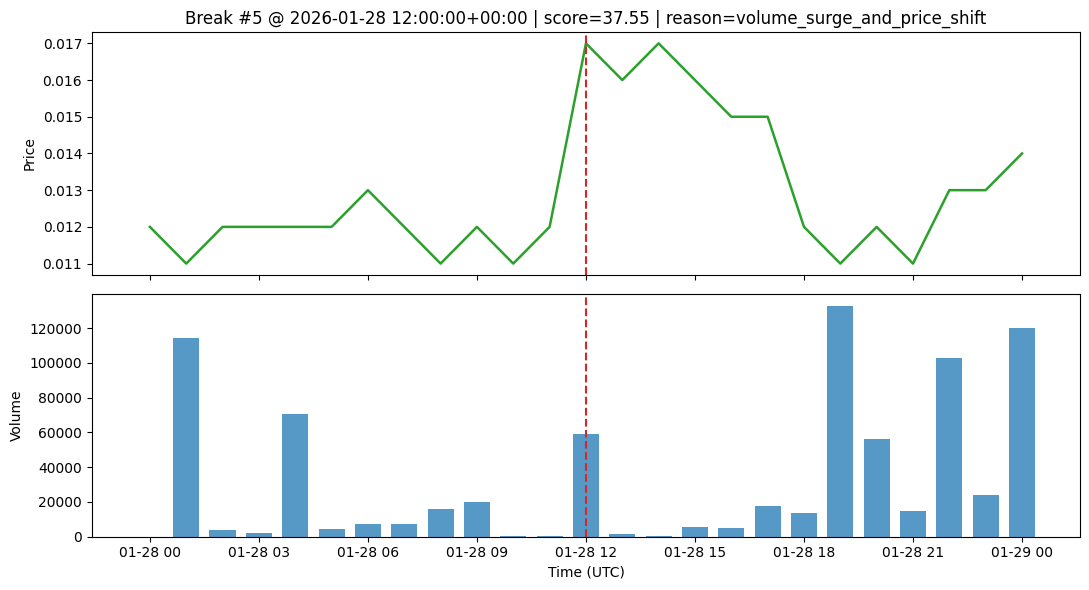

In [12]:
bars = sb_result.bars.copy()

for i, row in top_breaks.iterrows():
    ts = pd.Timestamp(row["break_timestamp"])
    ts = ts.tz_localize("UTC") if ts.tzinfo is None else ts.tz_convert("UTC")

    w0, w1 = ts - pd.Timedelta(hours=12), ts + pd.Timedelta(hours=12)
    local = bars.loc[(bars.index >= w0) & (bars.index <= w1)].copy()
    if local.empty:
        continue

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

    # Local price
    price_col = "price_plot" if "price_plot" in local.columns else "price_end"
    ax1.plot(local.index, local[price_col], color="tab:green", linewidth=1.8)
    ax1.axvline(ts, color="tab:red", linestyle="--", linewidth=1.5)
    ax1.set_ylabel("Price")
    ax1.set_title(
        f"Break #{i+1} @ {ts} | score={float(row['score']):.2f} | reason={row['reason']}"
    )

    # Local USD volume (fallback to contracts volume if needed)
    vol_col = "usd_volume" if "usd_volume" in local.columns else "volume"
    ax2.bar(local.index, local[vol_col], width=0.03, color="tab:blue", alpha=0.75)
    ax2.axvline(ts, color="tab:red", linestyle="--", linewidth=1.5)
    ax2.set_ylabel("USD volume" if vol_col == "usd_volume" else "Volume")
    ax2.set_xlabel("Time (UTC)")

    plt.tight_layout()
    plt.show()


## Step 8: News Around Top Break (±6h)

Берем top-break и скачиваем новости в окне ±6 часов.

Ограничения только:
- время (`start_date`, `end_date`)
- язык (`english`)

Без keyword-фильтрации по теме рынка.

In [25]:
from collectors.news_collector import NewsCollector

# Top break by score
row = top_breaks.sort_values("score", ascending=False, kind="stable").iloc[0]
break_ts = pd.Timestamp(row["break_timestamp"])
break_ts = break_ts.tz_localize("UTC") if break_ts.tzinfo is None else break_ts.tz_convert("UTC")

news_start = break_ts - pd.Timedelta(hours=6)
news_end = break_ts + pd.Timedelta(hours=6)

news = NewsCollector()
recent_news_df = news.search_gdelt(
    query=None,
    start_date=news_start,
    end_date=news_end,
    language="english",
    dedupe=False,
    max_records=1000,
    show_progress=True,
)

print(f"Top break timestamp (UTC): {break_ts}")
print(f"News window (UTC): {news_start} -> {news_end}")
print("Query: default broad GDELT base query")
print(f"Language: english")
print(f"Downloaded news rows: {len(recent_news_df)}")

news_cache_path = cache_dir / "top_break_news.parquet"
news_meta_path = cache_dir / "top_break_news_context.json"

news.save_to_parquet(recent_news_df, news_cache_path)
news_meta = {
    "break_timestamp_utc": break_ts.isoformat(),
    "window_start_utc": news_start.isoformat(),
    "window_end_utc": news_end.isoformat(),
    "query": None,
    "gdelt_base_query": "the",
    "language": "english",
    "dedupe": False,
    "rows": int(len(recent_news_df)),
    "top_break": {
        "reason": str(row.get("reason")),
        "score": float(row.get("score")),
        "price_return_pct": float(row.get("price_return_pct")) if pd.notna(row.get("price_return_pct")) else None,
        "volume_ratio": float(row.get("volume_ratio")) if pd.notna(row.get("volume_ratio")) else None,
    },
}
news_meta_path.write_text(json.dumps(news_meta, ensure_ascii=False, indent=2), encoding="utf-8")

recent_news_df

Top break timestamp (UTC): 2026-01-23 21:00:00+00:00
News window (UTC): 2026-01-23 15:00:00+00:00 -> 2026-01-24 03:00:00+00:00
Query: default broad GDELT base query
Language: english
Downloaded news rows: 126


,timestamp_utc,title,url,source,language,domain
0,2026-01-24 03:15:00+00:00,"Your brain can be trained , much like your muscles – a neurologist explains how to boost your brain health","http://northcountrynow.com/premium/theconversation/stories/your-brain-can-be-trained-much-like-your-muscles-a-neurologist-explains-how-to-boost-your,350455",United States,English,northcountrynow.com
1,2026-01-24 03:15:00+00:00,One - sided elections wont be sustainable : Awami League Mohibul Hassan Chowdhury on Bangladesh polls,http://www.batonrougepost.com/news/278827360/one-sided-elections-wont-be-sustainable-awami-league-mohibul-hassan-chowdhury-on-bangladesh-polls,United States,English,batonrougepost.com
2,2026-01-24 03:15:00+00:00,Robbie Williams surpasses The Beatles for most number one albums in the united kingdom,http://www.bgnes.com/entertainment/robbie-williams-surpasses-the-beatles-for-most-number-one-albums-in-the-uk,Bulgaria,English,bgnes.com
3,2026-01-24 03:15:00+00:00,Varied exercise boosts chances of a longer life,http://www.bgnes.com/health/varied-exercise-boosts-chances-of-a-longer-life,Bulgaria,English,bgnes.com
4,2026-01-24 03:15:00+00:00,Outgrowing colonial shadows : President Murmu inaugurates Granth Kutir at Rashtrapati Bhavan,http://www.cambodiantimes.com/news/278827401/outgrowing-colonial-shadows-president-murmu-inaugurates-granth-kutir-at-rashtrapati-bhavan,Cambodia,English,cambodiantimes.com
5,2026-01-24 03:15:00+00:00,49ers legendary QB John Brodie dies at 90,http://www.cambodiantimes.com/news/278827408/49ers-legendary-qb-john-brodie-dies-at-90,Cambodia,English,cambodiantimes.com
6,2026-01-24 03:15:00+00:00,China Daily Website - Connecting China Connecting the World,http://www.chinadaily.com.cn/www.chinadaily.com.cn/a/202601/24/WS6974053ea310d6866eb35807.html,China,English,chinadaily.com.cn
7,2026-01-24 03:15:00+00:00,China Daily Website - Connecting China Connecting the World,http://www.chinadaily.com.cn/www.chinadaily.com.cn/a/202601/24/WS6974087fa310d6866eb3581f.html,China,English,chinadaily.com.cn
8,2026-01-24 03:15:00+00:00,China Daily Website - Connecting China Connecting the World,http://www.chinadaily.com.cn/www.chinadaily.com.cn/a/202601/24/WS69742da9a310d6866eb35885.html,China,English,chinadaily.com.cn
9,2026-01-24 03:15:00+00:00,China Daily Website - Connecting China Connecting the World,http://www.chinadaily.com.cn/www.chinadaily.com.cn/a/202601/24/WS69742ee7a310d6866eb358af.html,China,English,chinadaily.com.cn


In [ ]:
recent_news_df

,timestamp_utc,title,url,source,language,domain
0,2026-01-24 03:15:00+00:00,"Your brain can be trained , much like your muscles – a neurologist explains how to boost your brain health","http://northcountrynow.com/premium/theconversation/stories/your-brain-can-be-trained-much-like-your-muscles-a-neurologist-explains-how-to-boost-your,350455",United States,English,northcountrynow.com
1,2026-01-24 03:15:00+00:00,One - sided elections wont be sustainable : Awami League Mohibul Hassan Chowdhury on Bangladesh polls,http://www.batonrougepost.com/news/278827360/one-sided-elections-wont-be-sustainable-awami-league-mohibul-hassan-chowdhury-on-bangladesh-polls,United States,English,batonrougepost.com
2,2026-01-24 03:15:00+00:00,Robbie Williams surpasses The Beatles for most number one albums in the united kingdom,http://www.bgnes.com/entertainment/robbie-williams-surpasses-the-beatles-for-most-number-one-albums-in-the-uk,Bulgaria,English,bgnes.com
3,2026-01-24 03:15:00+00:00,Varied exercise boosts chances of a longer life,http://www.bgnes.com/health/varied-exercise-boosts-chances-of-a-longer-life,Bulgaria,English,bgnes.com
4,2026-01-24 03:15:00+00:00,Outgrowing colonial shadows : President Murmu inaugurates Granth Kutir at Rashtrapati Bhavan,http://www.cambodiantimes.com/news/278827401/outgrowing-colonial-shadows-president-murmu-inaugurates-granth-kutir-at-rashtrapati-bhavan,Cambodia,English,cambodiantimes.com
5,2026-01-24 03:15:00+00:00,49ers legendary QB John Brodie dies at 90,http://www.cambodiantimes.com/news/278827408/49ers-legendary-qb-john-brodie-dies-at-90,Cambodia,English,cambodiantimes.com
6,2026-01-24 03:15:00+00:00,China Daily Website - Connecting China Connecting the World,http://www.chinadaily.com.cn/www.chinadaily.com.cn/a/202601/24/WS6974053ea310d6866eb35807.html,China,English,chinadaily.com.cn
7,2026-01-24 03:15:00+00:00,China Daily Website - Connecting China Connecting the World,http://www.chinadaily.com.cn/www.chinadaily.com.cn/a/202601/24/WS6974087fa310d6866eb3581f.html,China,English,chinadaily.com.cn
8,2026-01-24 03:15:00+00:00,China Daily Website - Connecting China Connecting the World,http://www.chinadaily.com.cn/www.chinadaily.com.cn/a/202601/24/WS69742da9a310d6866eb35885.html,China,English,chinadaily.com.cn
9,2026-01-24 03:15:00+00:00,China Daily Website - Connecting China Connecting the World,http://www.chinadaily.com.cn/www.chinadaily.com.cn/a/202601/24/WS69742ee7a310d6866eb358af.html,China,English,chinadaily.com.cn


In [18]:
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_colwidth', None)
news_df.title.drop_duplicates().reset_index(drop=True)

0                               Your brain can be trained , much like your muscles – a neurologist explains how to boost your brain health
1                                   One - sided elections  wont be sustainable : Awami League Mohibul Hassan Chowdhury on Bangladesh polls
2                                                   Robbie Williams surpasses The Beatles for most number one albums in the united kingdom
3                                                                                          Varied exercise boosts chances of a longer life
4                                             Outgrowing colonial shadows : President Murmu inaugurates Granth Kutir at Rashtrapati Bhavan
5                                                                                                49ers legendary QB John Brodie dies at 90
6                                                                              China Daily Website - Connecting China Connecting the World
7                          

In [20]:
news_df.domain.value_counts()

domain
singletonargus.com.au       5
webpronews.com              5
chinadaily.com.cn           4
portnews.com.au             4
torontosun.com              3
boredpanda.com              3
dailymail.co.uk             3
news18.com                  3
pressdemocrat.com           3
wandsworthguardian.co.uk    3
wmur.com                    3
bgnes.com                   2
cambodiantimes.com          2
dhakacourier.com.bd         2
burytimes.co.uk             2
cbc.ca                      2
dailygazette.com            2
executivegov.com            2
greeleytribune.com          2
heraldpalladium.com         2
livemint.com                2
reviewjournal.com           2
scmp.com                    2
southernliving.com          2
wbaltv.com                  2
yasstribune.com.au          2
northcountrynow.com         1
batonrougepost.com          1
925thebreeze.iheart.com     1
991thewhale.com             1
abbynews.com                1
b1047.com                   1
deadline.com                1
hot

In [21]:
query = "(domainis:reuters.com OR domainis:bloomberg.com)"

news_start = "2025-01-01"
news_end = "2026-01-18"
news_df = news.search_gdelt(
    query=query,
    start_date=news_start,
    end_date=news_end,
    language="english",
    dedupe=False,
    max_records=10000,
)


GDELT request retryable status 429 (attempt 1/6).
GDELT request retryable status 429 (attempt 1/6).


In [22]:
news_df

,timestamp_utc,title,url,source,language,domain
0,2025-02-05 17:30:00+00:00,Trump Administration Ramps Up Move to Scrub DEI From Government,https://www.bloomberg.com/news/articles/2025-02-05/trump-administration-ramps-up-move-to-scrub-dei-from-government,United States,English,bloomberg.com
1,2025-02-05 17:45:00+00:00,"French Premier Survives No - Confidence Vote , Securing New Budget",https://www.bloomberg.com/news/articles/2025-02-05/french-premier-survives-no-confidence-vote-securing-new-budget,United States,English,bloomberg.com
2,2025-02-05 17:45:00+00:00,NexGen CEO Says He in Advanced Talks to Sell More Uranium to US Utilities,https://www.bloomberg.com/news/articles/2025-02-05/nexgen-ceo-says-he-s-in-advanced-talks-to-sell-more-uranium-to-us-utilities,United States,English,bloomberg.com
3,2025-02-05 18:45:00+00:00,Cash - Flush Florida Seeks to Retire $1 . 7 Billion of State Debt,https://www.bloomberg.com/news/articles/2025-02-05/cash-flush-florida-seeks-to-retire-1-7-billion-of-state-debt,United States,English,bloomberg.com
4,2025-02-05 18:45:00+00:00,Control of US - UK Military Satellite System Is Key to Chagos Deal,https://www.bloomberg.com/news/articles/2025-02-05/control-of-us-uk-military-satellite-system-is-key-to-chagos-deal,United States,English,bloomberg.com
...,...,...,...,...,...,...
9851,2026-01-18 11:30:00+00:00,China New Tech Stock Boom Leaves Its Economic Malaise Behind,https://www.bloomberg.com/news/articles/2026-01-18/china-s-new-tech-stock-boom-leaves-its-economic-malaise-behind,United States,English,bloomberg.com
9852,2026-01-18 11:30:00+00:00,FBI Asks Agents to Travel to Minneapolis for Temporary Duty,https://www.bloomberg.com/news/articles/2026-01-18/fbi-asks-agents-to-voluntarily-travel-to-minneapolis,United States,English,bloomberg.com
9853,2026-01-18 11:30:00+00:00,BOJ Keeps Yen Watchers on Edge for Rate - Hike Clues,https://www.bloomberg.com:443/news/articles/2026-01-17/boj-keeps-yen-watchers-on-edge-for-rate-hike-clues,United States,English,bloomberg.com
9854,2026-01-18 11:30:00+00:00,DOJ Probes Minnesota Governor Over Immigration Enforcement,https://www.bloomberg.com:443/news/articles/2026-01-17/doj-probes-minnesota-governor-walz-over-immigration-enforcement,United States,English,bloomberg.com


In [24]:
news_df

,timestamp_utc,title,url,source,language,domain
0,2025-02-05 17:30:00+00:00,Trump Administration Ramps Up Move to Scrub DEI From Government,https://www.bloomberg.com/news/articles/2025-02-05/trump-administration-ramps-up-move-to-scrub-dei-from-government,United States,English,bloomberg.com
1,2025-02-05 17:45:00+00:00,"French Premier Survives No - Confidence Vote , Securing New Budget",https://www.bloomberg.com/news/articles/2025-02-05/french-premier-survives-no-confidence-vote-securing-new-budget,United States,English,bloomberg.com
2,2025-02-05 17:45:00+00:00,NexGen CEO Says He in Advanced Talks to Sell More Uranium to US Utilities,https://www.bloomberg.com/news/articles/2025-02-05/nexgen-ceo-says-he-s-in-advanced-talks-to-sell-more-uranium-to-us-utilities,United States,English,bloomberg.com
3,2025-02-05 18:45:00+00:00,Cash - Flush Florida Seeks to Retire $1 . 7 Billion of State Debt,https://www.bloomberg.com/news/articles/2025-02-05/cash-flush-florida-seeks-to-retire-1-7-billion-of-state-debt,United States,English,bloomberg.com
4,2025-02-05 18:45:00+00:00,Control of US - UK Military Satellite System Is Key to Chagos Deal,https://www.bloomberg.com/news/articles/2025-02-05/control-of-us-uk-military-satellite-system-is-key-to-chagos-deal,United States,English,bloomberg.com
...,...,...,...,...,...,...
9851,2026-01-18 11:30:00+00:00,China New Tech Stock Boom Leaves Its Economic Malaise Behind,https://www.bloomberg.com/news/articles/2026-01-18/china-s-new-tech-stock-boom-leaves-its-economic-malaise-behind,United States,English,bloomberg.com
9852,2026-01-18 11:30:00+00:00,FBI Asks Agents to Travel to Minneapolis for Temporary Duty,https://www.bloomberg.com/news/articles/2026-01-18/fbi-asks-agents-to-voluntarily-travel-to-minneapolis,United States,English,bloomberg.com
9853,2026-01-18 11:30:00+00:00,BOJ Keeps Yen Watchers on Edge for Rate - Hike Clues,https://www.bloomberg.com:443/news/articles/2026-01-17/boj-keeps-yen-watchers-on-edge-for-rate-hike-clues,United States,English,bloomberg.com
9854,2026-01-18 11:30:00+00:00,DOJ Probes Minnesota Governor Over Immigration Enforcement,https://www.bloomberg.com:443/news/articles/2026-01-17/doj-probes-minnesota-governor-walz-over-immigration-enforcement,United States,English,bloomberg.com


## Итог

Pipeline теперь линейный и компактный:
1. USD volume на полной истории + сравнение до/после cutoff.
2. Формальное применение cutoff и сбор рабочего датасета.
3. Сглаженная цена с адаптацией к ликвидности.
4. Детерминированный отбор брейков с непересекающимися событиями (`break_radius`).
5. Обзорные графики по всей post-cutoff истории с отметками брейков.
6. Локальная визуальная валидация top-5 без наложений.
7. Загрузка новостей вокруг top-break в окне ±6 часов через GDELT.

Кэш артефактов шага 8:
- `data/demo_cache/top_break_news.parquet`
- `data/demo_cache/top_break_news_context.json`